</font>
<font size=6  color=#003366> <div style="text-align: center"> [LGBIO2050] - Medical Imaging <br><br> 
<div style="text-align: center"> Intro -  Python Good Practice and Applications to Image Processing </font> <br><br>

<font size=5  color=#003366>
<div style="text-align: left"> Professors :   
<font size=4  color=#003366>
<div style="text-align: left"> Prof. G. Kerckhofs  
<div style="text-align: left"> Prof. J. Lee <br>
<div style="text-align: left"> Prof. B. Macq <br>
<div style="text-align: left"> Prof. G. Duchêne
<font size=5  color=#003366>
    
<br><br>
<div style="text-align: left"> Teaching assistants : 
<font size=4  color=#003366>
<div style="text-align: left">Pauline Hermans (pauline.hermans@uclouvain.be)<br>
<div style="text-align: left">Maxence Wynen (maxence.wynen@uclouvain.be)<br>
<div style="text-align: left">Colin Vanden Bulcke (colin.vandenbulcke@uclouvain.be)
<font size=5  color=#003366>
<div style="text-align: right"> 2025-2026 </div>
<br>
</font>

<div style="text-align: justify">The objective of this first session is two-fold. On the one hand, excercises 1 and 2 have for purpose to give you some advice to write efficient python code. Even though you already used Python, we strongly promote you to do these excercices. On the other hand, exercise 3 contains traditional image processing applications. <br> <br>


<font size=6 color=#009999> 1. Conditional Indexing </font> <br> <br>

<font size=5 color=#009999> 1.1 Context  </font>

It is possible to retrieve specific elements of a list or a numpy array by using simple indices. For example, 

   - <samp>array[5]</samp> selects the 6th element of the array;
   - <samp>array[0:2]</samp> selects the first 3;
   - <samp>array[-1]</samp> selects the last.
   
In this excercice, we will explore an other indexing method that is much more powerful! <br><br>

<font size=5 color=#009999> 1.2 Fancy indexing on a vector  </font>

First, a boolean array can be created by applying a condition over all elements of an array, e.g. <samp>bool_array  = array > 0</samp> will create a boolean array of the original array size in which an index is <samp>True</samp> if the value in <samp>array</samp> is greater than zero. This boolean array can then be used to index values of an array depending on the value the boolean at this index, if it is <samp>True</samp> or not (ex: <samp>array2\[bool_array\]</samp>). <br>
<ol>
   <li> Generate a numpy array (<samp>randomVec</samp>) of size 100 with random integer values between -20 and 20;
   <li> Generate a numpy array (<samp>booleanVec</samp>) of size 100 within which <samp>booleanVec[i]</samp> is <samp>True</samp> only if <samp>randomVec[i]</samp> is greater than 0 <font color=#cc3300> without using any for loop! </font>; 
   <li> Use <samp>booleanVec</samp> to compute the mean of the strictly positive values in <samp>randomVec</samp> <font color=#cc3300> again without using any for loop! </font>;  
   <li>Now compute the mean of the strictly positive even values.
</ol>

In [421]:
import numpy as np 

rng = np.random.default_rng()
randomVec = rng.integers(-20, 21, 100)
booleanVec = randomVec >= 0
evenVec = randomVec % 2 == 0  

print(randomVec)
print(booleanVec)
print(evenVec)

mean = np.mean(randomVec[booleanVec])

mean2 = 0
count = 0
for elements in randomVec:
    if elements >= 0:
        mean2 += elements
        count += 1
mean2= mean2/count

print("the mean with booleanVec is: ", mean)
print("The correct mean of all positive numbers is: ", mean2)

meanEven = np.mean(randomVec[booleanVec & evenVec])

meanEven2 = 0
count2 = 0
for elements in randomVec:
    if (elements >= 0) and (elements %2 == 0):
        meanEven2 += elements
        count2 += 1
meanEven2= meanEven2/count2

print("the mean of positive even numbers with booleanVec is: ", meanEven)
print("The correct mean of positive even numbers is: ", meanEven2)

[  4  -3  -7  -7  -6 -14 -17  19  11   6 -10  12  -7  -3 -16 -10   8  13
   8   8  10   1  -1  -2 -20 -18  10  17 -14   4   9  -2   3 -12  17  12
  -4 -17   6   1  10   9  -2   5 -17 -13  -7  19  -1  -7   1  10  10  11
 -18  16  10  19  11   8  -9  16   8  -6  -1  15   3 -12   1  18 -18   2
  11 -17  17  15   0 -10 -19  -4  10  12  -7  17  15  -5   8  16 -10   4
  -3  14 -19  19  -9  -6  20  -6   3  12]
[ True False False False False False False  True  True  True False  True
 False False False False  True  True  True  True  True  True False False
 False False  True  True False  True  True False  True False  True  True
 False False  True  True  True  True False  True False False False  True
 False False  True  True  True  True False  True  True  True  True  True
 False  True  True False False  True  True False  True  True False  True
  True False  True  True  True False False False  True  True False  True
  True False  True  True False  True False  True False  True False False
  True Fa

<font size=5 color=#009999> 1.3 Fancy indexing on an array and execution time comparison </font>

Perform again the previous steps with an intial random numpy array of size 5000x5000 with random integer values between -20 and 20. Compare execution times of the point 4 with an implementation which uses for loops. <font color=#cc3300>Hint: time.time() returns the exact time at the moment the function is called.</font>

In [422]:
import time, datetime

rng = np.random.default_rng()
randomMat = rng.integers(-20, 21, (5000, 5000))
booleanMat = randomMat >= 0
evenMat = randomMat % 2 == 0  

startMean = time.time()
mean = np.mean(randomVec[booleanVec])
intervalMean = time.time() - startMean

print("Total time for the mean of positive values: ", intervalMean)

startMeanEven = time.time()
meanEven = np.mean(randomVec[booleanVec & evenVec])
intervalMeanEven = time.time() - startMeanEven
print("Total time for the mean of positive even values: ", intervalMeanEven)

startMeanEvenLoop = time.time()
meanEven2 = 0
count2 = 0
for row in range(0, len(randomMat)):
    for elements in randomMat[row]:
        if (elements >= 0) and (elements %2 == 0):
            meanEven2 += elements
            count2 += 1
meanEven2= meanEven2/count2

intervalMeanEvenLoop = time.time() - startMeanEvenLoop
print("Total time for the mean of positive even values with a loop: ", intervalMeanEvenLoop)





Total time for the mean of positive values:  6.461143493652344e-05
Total time for the mean of positive even values:  3.0994415283203125e-05
Total time for the mean of positive even values with a loop:  2.2384719848632812


<font size=6 color=#009999> 2. Variable Mutability </font> <br> <br>

<font size=5 color=#009999> 2.1 Context </font>

Everything in Python is an object. And what every newcomer to Python should quickly learn is that all objects in Python can be either mutable or immutable. <br>
Objects of built-in types like list, set or dict are mutable (the object can be changed after it is created); Objects of built-in types like int, float, bool, str or tuple are immutable (the object can't be changed). <br> 

This property of python variables will be crucial when they are given as argument to a function. In python, arguments are "passed by reference" instead of "passed by value". It means that the pointer to the variable is passed to the function and not a copy of the variable. Any change that is performed inside a function will afect the value of the variable in the whole script! <br>
Believe us, if you do not pay attention to that, you will hate your code for returning strange results ;)<br><br>

<font size=5 color=#009999> 2.2 Add and average function </font>

<div style="text-align: justify">We provide you the <samp>add_and_average</samp> function which adds a given increment value to every item in a sequence and then computes the mean of it. Apply this function on a list and a numpy array and see if the list/array changes after this call. If it is the case, change the function to solve the problem. <font color=#cc3300>Hint: copy library is a good choice.</font>

In [423]:
import copy 
import numpy

nparray = numpy.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
liste = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

def add_and_average(sequence, increment=0): 
    nb_items = 0
    copyofsequence = sequence.copy()
    for item in sequence: 
        copyofsequence[nb_items] += increment
        nb_items += 1 
    return sum(copyofsequence)/nb_items

print("added on a numpy array: ", add_and_average(nparray, 10))
print("array is now: ", nparray)
print("added on a list: ", add_and_average(liste, 10))
print("list is now: ", liste)



added on a numpy array:  15.5
array is now:  [ 1  2  3  4  5  6  7  8  9 10]
added on a list:  15.5
list is now:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


<font size=6 color=#009999> 3. Basic image operations and image visualization </font> <br>

We will use 2D numpy arrays to store and manipulate images. We shall start by a general overview of some basic operations on images.

In these exercises, the objective is to implement **by yourself** basic algorithms. You should then use only the numpy (and eventually math) library for your image processing codes. 

<font size=5 color=#009999> 3.1. Exercise 1 - Import an image </font>

Open the falcon.jpg image using the skimage library. 
- Print the shape of the image
- If it is an RGB image, change it to a 1 channel (grayscale image) and display it with different colormaps using the matplotlib library.

The shape of the image is:  (518, 920, 3)
Is the image RGB?  True
The shape of the image is:  (518, 920)
Transform successfull?  True


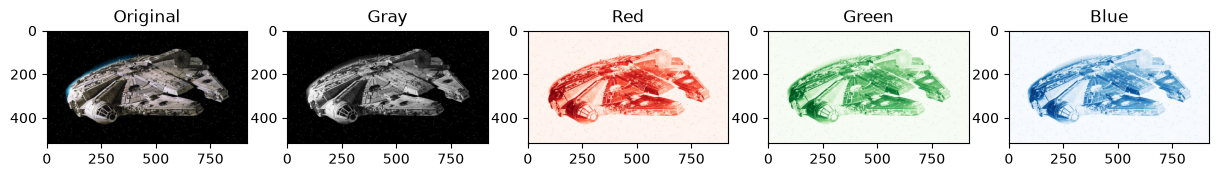

In [424]:
from skimage.io import imread
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

original_image = imread("./falcon.jpg")
redImage = original_image[:, :, 0]
greenImage = original_image[:, :, 1]
blueImage = original_image[:, :, 2]
print("The shape of the image is: ", original_image.shape)
print("Is the image RGB? ", len(original_image.shape) == 3)

greyImage = copy.copy(original_image)
greyImage = rgb2gray(greyImage)
print("The shape of the image is: ", greyImage.shape)

"""
The shape is intented to be the number of line * number of columns. Each line is a vector of points with number_of_colums elements. 
Each element is the intensity of grey btw 0 (full black) and 1 (full white)
"""

print("Transform successfull? ", len(greyImage.shape)==2)

fig = plt.figure(figsize=(15,5))
for (i,image,cmap,title) in zip(range(5), [original_image, greyImage, redImage, greenImage, blueImage], [None, "gray", "Reds", "Greens", "Blues"], ['Original', 'Gray', 'Red', 'Green', 'Blue']):
    ax = fig.add_subplot(1, 5, i+1)
    if (i == "original_image"):
        plt.imshow(image)
    else: 
        plt.imshow(image, cmap=cmap)
    plt.title(title)



<font size=5 color=#009999> 3.2. Exercise 2 - Flip an image </font>

Use the greyscale image of the falcon and flip it horizontally and vertically. This can be easily done with the "::-1" operator. For example, if we have 
$$ list = [1,2,3,4]$$
then 
$$ list[::-1] ~~\text{is}~~ [4,3,2,1]$$

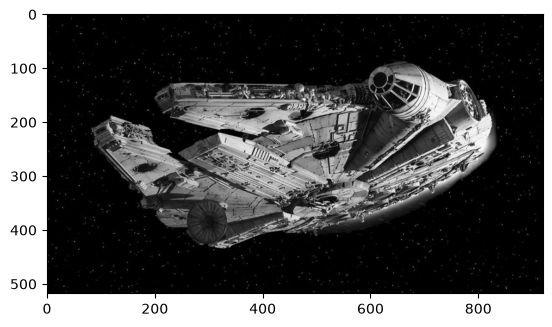

In [425]:
invertedImage = greyImage[::-1, ::-1]

plt.imshow(invertedImage, cmap="grey")
plt.show()



<font size=5 color=#009999> *3.3. Exercise 3 - Crop an image* </font>

Now, take your previous grayscale channel image and crop it, i.e. cut a part of the image to reframe it.
Let the origin be the coordinate of upper-left corner and end the coordinate of the bottom-right corner in a 2-dimensional space. The pixel at coordinate $(x, y)$ in the new image is equal to the pixel located at coordinate $(x + origin.x, y + origin.y)$ in the old image.
- For this exercise, crop the image between 50 and 400 in the x axis and between 150 and 700 in the y axis. 
- In an image is the horizontal/vertical axis corresponding to the x/y coordinate?

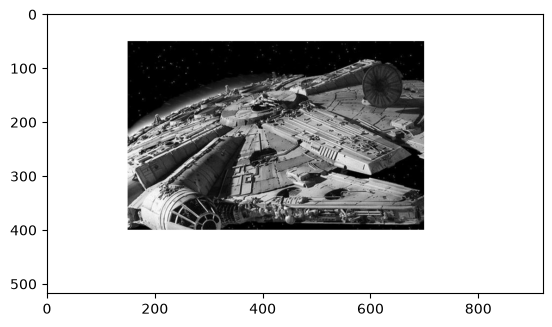

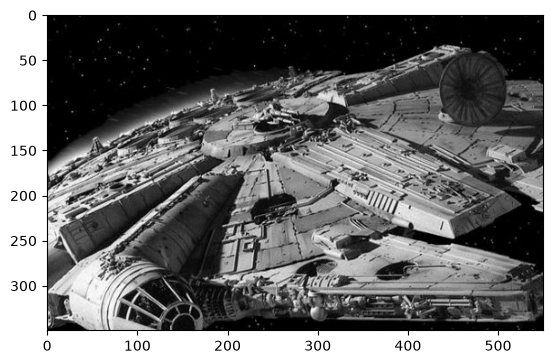

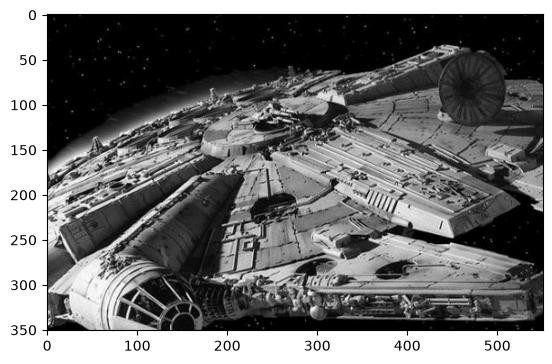

In [426]:
import numpy as np 

croppedImage2 = copy.copy(greyImage)
croppedImage2[:50, :] = np.ones(croppedImage2[:50, :].shape)
croppedImage2[400:, :] = np.ones(croppedImage2[400:, :].shape)
croppedImage2[:, :150] = np.ones(croppedImage2[:, :150].shape)
croppedImage2[:, 700:] = np.ones(croppedImage2[:, 700:].shape)
plt.imshow(croppedImage2, cmap="grey")
plt.show()

croppedImage = greyImage[50:400, 150:700]
plt.imshow(croppedImage, cmap="grey")
plt.show()

### AI version explenation ### 

x0, x1 = 50, 400
y0, y1 = 150, 700

croppedImage3 = np.zeros((x1 - x0 + 1, y1 - y0 + 1))

for x in range(croppedImage3.shape[0]):
    for y in range(croppedImage3.shape[1]):
        croppedImage3[x, y] = greyImage[x + x0, y + y0]

plt.imshow(croppedImage3, cmap="grey")
plt.show()

<font size=5 color=#009999> 3.4. Exercise 4 - Scale an image </font>

In this exercise, we will scale the falcon image. It can be a scale down or up. There are several methods available to interpolate the pixels. We will use the simplest possible algorithm: Nearest Neighbor. <br>

To compute the rescaled image, we need the ratio for both horizontal and vertical axes: 
$$x_{ratio} ~=~ oldImg_x ~/~ newImg_x ~~~\text{and}~~~ y_{ratio} ~=~ oldImg_y ~/~ newImg_y$$
The pixel at coordinate $(x, y)$ in the new image is equal to the pixel that is located at coordinate $(\text{floor}(x * x_{ratio}), \text{floor}(y * y_{ratio}))$

- Scale the image in the 200x200 size. You should use numpy library and an additional library with the floor function. Which one do you choose?

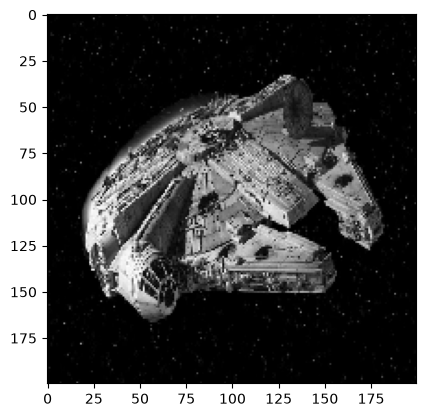

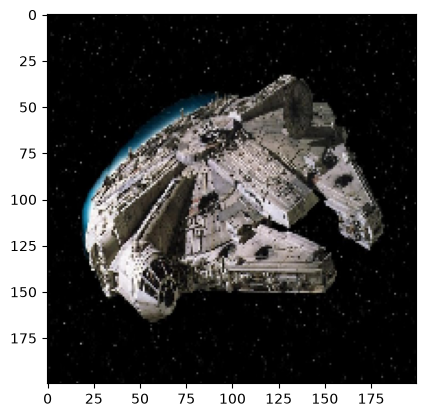

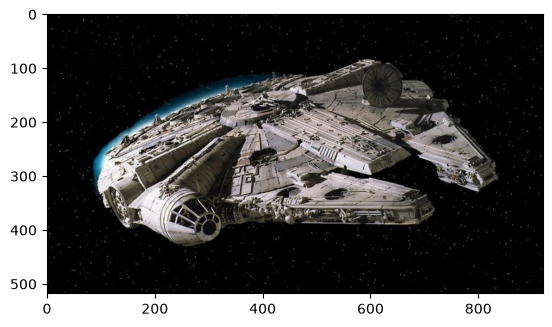

In [427]:
from math import floor
import numpy as np

### 2D version ### 
x_ratio = greyImage.shape[0]/200
y_ratio = greyImage.shape[1]/200

scaledImage = np.zeros((200, 200))

for x in range(0, 200):
    for y in range(0, 200):
        scaledImage[x, y] = greyImage[floor(x*x_ratio), floor(y*y_ratio)]


plt.imshow(scaledImage, cmap="grey")
plt.show()

### 3D version ### 
scaledImage2 = np.zeros((200, 200, 3))

for x in range(0, 200):
    for y in range(0, 200):
        scaledImage2[x, y] = original_image[floor(x*x_ratio), floor(y*y_ratio)]
scaledImage2 = np.asarray(scaledImage2, dtype=int)
        

plt.imshow(scaledImage2)
plt.show()

plt.imshow(original_image)
plt.show()




<font size=5 color=#009999> 3.5. Exercise 5 - Change the luminosity </font>

We can change the luminosity of an image by adding a constant value to each of the three channels (if this is a RGB image) or only the single channel for a grayscale image. 
- Increase the luminosity of the falcon by adding a constant value which is equal to 3 times the mean pixel value of the image. Can you implement it in one line of code ?

38.578181131442


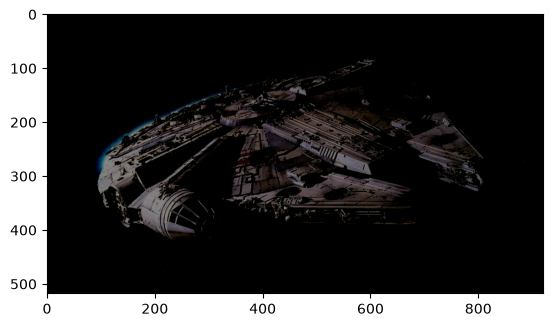

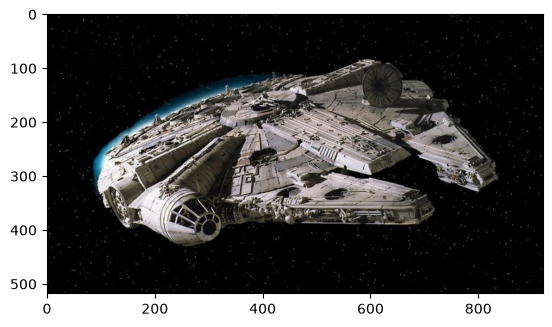

In [465]:
luminarImage3 = copy.copy(original_image)

luminarImage = np.asarray(luminarImage3, dtype=np.float16)

meanValue = np.mean(original_image)
print(meanValue)


luminarImage = luminarImage - 3*meanValue

luminarImage = np.clip(luminarImage, 0, 255)

luminarImage = luminarImage.astype(np.uint8)

#One line code

luminarImage2 = (np.asarray(luminarImage3, dtype=np.float16) - 3*np.mean(original_image)).clip(0, 255).astype(np.uint8)

plt.imshow(luminarImage2)
plt.show()

plt.imshow(original_image)
plt.show()

<font size=5 color=#009999> 3.6. Exercise 6 - Linear Filtering </font>

With little doubt the linear filter is one of the most used and simple filter in image processing. It calculates a weighted summation of all pixel values in a small neighborhood (small compared to the image size). It does so for all shifted neighborhoods in an image and all weighted sums thus form a new image. In signal processing this would be called a moving (weighted) average filter.

Let F be the discrete function with all samples of the original image and let W be the weight function, the result image G then is called the filtering of the image by the kernel W:
$$ G(i,j) = \sum_{k=-\infty}^{+\infty}\, \sum_{l=-\infty}^{+\infty} F(i+k, j+l)\,W(k,l)$$

In practice we have to deal with the fact that the image is defined only on a finite domain. Then the indices (i+l,j+l) can point outside the image (see the border problem) and we have to decide what value to use for F(i+k,j+l).

In practice the weight function has non zero values only in small neighborhood of the origin. Assume that W(k,l) is non zero only in the neighborhood for k=−K,..,+K and l=−L,..,+L.

- Implement a function called linear_filter which takes in argument an image F and a filter G and returns a filtered image. Test it with the falcon as F and np.ones((5,5))/25 as W. 

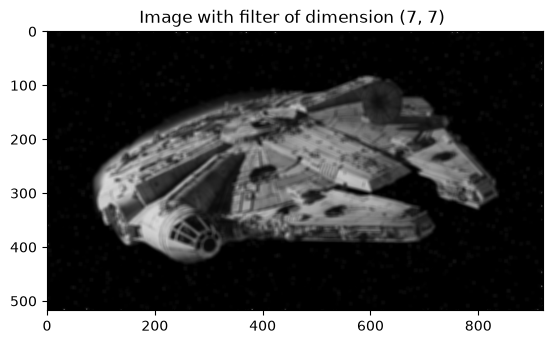

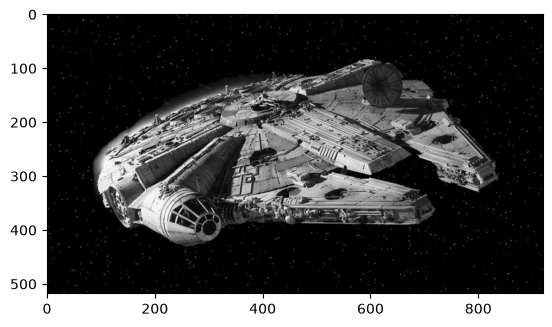

In [463]:
def linear_filter(f, w):
    g = copy.copy(f)
    k = len(w)//2
    l = len(w[0])//2
    for i in range(0, f.shape[0]):
        for j in range(0, f.shape[1]):
            if (i-k >= 0 and i+k+1 <= f.shape[0] and j-l >= 0 and j+l+1 <= f.shape[1]): 
                g[i, j] = np.sum(np.multiply(f[i-k:i-k+len(w), j-l:j-l+len(w[0])], w))
    return g

w = np.ones((7, 7))/121

filtered_image = linear_filter(greyImage, w)
plt.imshow(filtered_image, cmap="gray")
plt.title(f"Image with filter of dimension {w.shape} ")
plt.show()

plt.imshow(greyImage, cmap="gray")
plt.show()
